### Importing the Libraries

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

### Root data directory path

In [14]:
data_dir = r"C:\Users\Rahul Kumar Tiwari\Desktop\projects\Signature_Recognition\notebook\data"

### Total Number of Classes

In [16]:
class_name = os.listdir(data_dir)
len(class_name)

2

In [17]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T, datasets

### Checking cuda availability

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:{}".format(device))

Device:cpu


### Transforming the Data

In [21]:
data_transform = T.Compose([

                            T.Resize(size=(224, 224)), # Resizing the image to be 224 by 224
                            T.RandomRotation(degrees=(-20,+20)), # Randomly Rotate Images by +/- 20 degrees, Image augementation
                            T.ToTensor(), # converting the dimension from (height, weight, channel) to (channel, height, weight)                          
                            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalize by 3 means 3 std's of the image net
])

In [22]:
data = datasets.ImageFolder(data_dir, transform=data_transform)
total_count = len(data)

In [23]:
total_count

2640

In [24]:
data.classes

['Forged', 'Original']

### Splitting the Data

In [25]:
train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count

train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [26]:
train_data.dataset

Dataset ImageFolder
    Number of datapoints: 2640
    Root location: C:\Users\Rahul Kumar Tiwari\Desktop\projects\Signature_Recognition\notebook\data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [27]:
len(train_data.indices)

1584

In [28]:
len(test_data.indices)

264

In [29]:
len(val_data.indices)

792

### Defining some functions

In [31]:
def show_image(image, label, get_denormalize = True):
    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    if get_denormalize == True:
        image = image*std + mean
        image = np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)

    else:
        plt.imshow(image)
        plt.title(label)


def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim = 1)
    top_p, top_class = y_pred.topk(1,dim = 1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

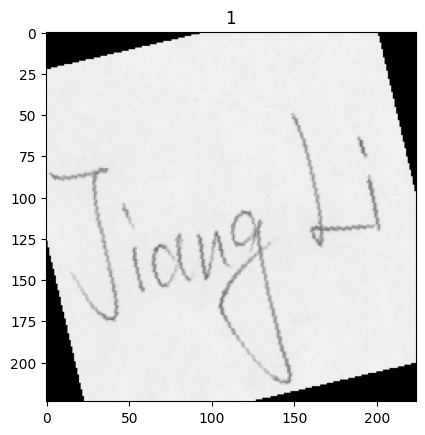

In [33]:
img, label = train_data[0]
show_image(img, label)

### Data Loader

In [34]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print("No. of batches in trainloader:{}".format(len(trainloader)))
print("No. of Total examples:{}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print("No. of batches in validationloader:{}".format(len(validationloader)))
print("No. of Total examples:{}".format(len(validationloader.dataset)))

testloader = DataLoader(test_data, batch_size=32, shuffle=True)
print("No. of batches in testloader:{}".format(len(testloader)))
print("No. of Total examples:{}".format(len(testloader.dataset)))

No. of batches in trainloader:50
No. of Total examples:1584
No. of batches in validationloader:25
No. of Total examples:792
No. of batches in testloader:9
No. of Total examples:264


### Model

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms


In [37]:
model = models.resnet34(pretrained=True)

C:\Users\Rahul Kumar Tiwari\desktop\projects\Signature_Recognition\SR\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Rahul Kumar Tiwari\desktop\projects\Signature_Recognition\SR\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\Rahul Kumar Tiwari/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|█████████████████████████████████████████████████████████████████████████████| 83.3M/83.3M [00:08<00:00, 10.4MB/s]


In [38]:
model.fc = nn.Sequential(
      nn.Dropout(0.1),
      nn.Linear(model.fc.in_features, len(class_name))
  )

model = model.to(device)

criterian = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [45]:
def train(model, criterian, optimizer, train_dataloader, test_dataloader):
    total_train_loss = 0
    total_test_loss = 0
    
    model.train()
    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            
            output = model(images)

            loss = criterian(output, idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)

            loss = criterian(output, idxs)
            total_test_loss += loss.item()

    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(test_data)
    print(f'Train loss:{train_acc:.4f} Test loss: {test_acc:.4f}')

In [46]:
%%time
epochs = 5
for i in range(epochs):
    print(f"Epoch {i + 1}/{epochs}")
    train(model, criterian, optimizer, trainloader, validationloader)

Epoch 1/5


Train loss:0.0077 Test loss: 0.0134
Epoch 2/5


Train loss:0.0004 Test loss: 0.0003
Epoch 3/5


Train loss:0.0005 Test loss: 0.0001
Epoch 4/5


Train loss:0.0008 Test loss: 0.0064
Epoch 5/5


Train loss:0.0002 Test loss: 0.0001
CPU times: total: 1h 21min 21s
Wall time: 13min 45s


### Model Saving

In [51]:
Path = r'C:\\Users\\Rahul Kumar Tiwari\\desktop\\projects\\Signature_Recognition\\notebook\\model.pt'
torch.save(model, Path)

In [47]:
pwd

'C:\\Users\\Rahul Kumar Tiwari\\desktop\\projects\\Signature_Recognition\\notebook'

### Loading Torch Model

In [53]:
model = torch.load(Path, weights_only=False)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Evaluation

In [54]:
def evaluate(model, criterian, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterian(output, idxs)
            total_test_loss += loss.item()

    test_acc = total_test_loss / len(val_data)
    print(f'Test Loss: {test_acc : .4f}')

In [55]:
evaluate(model, criterian, optimizer, testloader)

Test Loss:  0.0000


### Prediction

In [57]:
label_names = data.classes
label_names

['Forged', 'Original']

In [61]:
from PIL import Image

image = Image.open(r'C:\Users\Rahul Kumar Tiwari\Desktop\projects\Signature_Recognition\notebook\data\Original\original_1_1.png')
preprocess = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image = image[:3]

image = image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

print(f'Predicted label : {pred_label.item()}')

predicted_class_name = label_names[pred_label.item()]

print(f'Predicted class name: {predicted_class_name}')


Predicted label : 1
Predicted class name: Original
